# Demonstration of MUSE

This is a demonstration of MUSE analysis on a multi-modality simulated data.

Feng Bao @ Altschuler & Wu Lab @ UCSF 2022.

Software provided as is under MIT License.

## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# import tensorflow as tf
# import os
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# tf.get_logger().setLevel('ERROR')
np.random.seed(0)

## Generate simulation data


Simulation parameters

In [2]:
latent_dim = 100
num_cluster = 10
sample_size = 1000
latent_code_dim = 30
observed_data_dim = 500
sigma_1 = 0.1  
sigma_2 = 0.1
decay_coef_1 = 0.5 
decay_coef_2 = 0.1
merge_prob = 0.7



Use simulation tool to generate multi-modality data

In [3]:
data = simulation.multi_modal_simulator(
    num_cluster,
    sample_size,
    observed_data_dim,
    observed_data_dim,
    latent_code_dim,
    sigma_1,
    sigma_2,
    decay_coef_1,
    decay_coef_2,
    merge_prob,
)
data_a = data["data_a_dropout"]
data_b = data["data_b_dropout"]
label_a = data["data_a_label"]
label_b = data["data_b_label"]
label_true = data["true_cluster"]

## Analyses based on single modality

Learn features from single modality

In [4]:
view_a_feature = PCA(n_components=latent_dim).fit_transform(data_a)
view_b_feature = PCA(n_components=latent_dim).fit_transform(data_b)

In [5]:
data_ab = data_a + data_b
view_ab_feature = PCA(n_components=latent_dim).fit_transform(data_ab)

In [6]:
print(f"data_a shape: {data_a.shape}")
print(f"data_b shape: {data_b.shape}")
print(f"view_a_feature shape: {view_a_feature.shape}")
print(f"view_b_feature shape: {view_b_feature.shape}")

data_a shape: (1000, 500)
data_b shape: (1000, 500)
view_a_feature shape: (1000, 100)
view_b_feature shape: (1000, 100)


Perform clustering using PhenoGraph

In [7]:
view_a_label, _, _ = phenograph.cluster(view_a_feature)
view_b_label, _, _ = phenograph.cluster(view_b_feature)
view_ab_label, _, _ = phenograph.cluster(view_ab_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07139134407043457 seconds
Jaccard graph constructed in 0.16569972038269043 seconds
Wrote graph to binary file in 0.007514476776123047 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.54231
After 3 runs, maximum modularity is Q = 0.544086
Louvain completed 23 runs in 0.22683095932006836 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.5882325172424316 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06904196739196777 seconds
Jaccard graph constructed in 0.13350558280944824 seconds
Wrote graph to binary file in 0.004750490188598633 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.76258
Louvain completed 21 runs in 0.17022299766540527 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.4902312755584717

## Combined analysis using MUSE

MUSE learns the joint latent representation

In [11]:
outputs = muse.dual_muse_fit_predict(
    [data_a, data_b],
    [data_ab],
    [view_a_label, view_b_label],
    [view_ab_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=1,
    weight_penalty=5,
    triplet_lambda=5,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
#epoch: 0/200 	 total loss: 1209.32 	 sc loss: 707.09 	 st loss: 495.60 	 infoNCE: 6.63 	 sc recon: 0.04 	 st recon: 0.03 	 sc sparse: 707.05 	 st sparse: 495.57 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 50/200 	 total loss: 1132.21 	 sc loss: 665.71 	 st loss: 466.29 	 infoNCE: 0.21 	 sc recon: 0.01 	 st recon: 0.01 	 sc sparse: 665.70 	 st sparse: 466.27 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 100/200 	 total loss: 1064.29 	 sc loss: 626.01 	 st loss: 438.18 	 infoNCE: 0.10 	 sc recon: 0.01 	 st recon: 0.01 	 sc sparse: 626.01 	 st sparse: 438.17 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 150/200 	 total loss: 998.99 	 sc loss: 587.79 	 st loss: 411.14 	 infoNCE: 0.06 	 sc recon: 0.01 	 st recon: 0.01 	 sc sparse: 587.78 	 st sparse: 411.13 	 sc trip: 0.00 	 st trip: 0.00
#epoch: 0/200 	 total loss: 945.97 	 sc loss: 556.56 	 st loss: 388.38 	 infoNCE: 1.03 	 sc recon: 0.01 	 st recon: 0.01 	 sc sparse: 550.95 	 st spa

## Perform clustering
PhenoGraph clustering

In [12]:
latent_sc, latent_st = outputs[0], outputs[1]
muse_label_sc, _, _ = phenograph.cluster(latent_sc)
muse_label_st, _, _ = phenograph.cluster(latent_st)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06718921661376953 seconds
Jaccard graph constructed in 0.2826046943664551 seconds
Wrote graph to binary file in 0.0033311843872070312 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.896716
Louvain completed 21 runs in 0.7998778820037842 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.3897011280059814 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06856179237365723 seconds
Jaccard graph constructed in 0.2810697555541992 seconds
Wrote graph to binary file in 0.003376483917236328 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.828086
Louvain completed 21 runs in 0.8372085094451904 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.4277477264404297 seconds


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

view_a_feature: (1000, 100)
X_embedded: (1000, 2)
label_true: (1000,)
laber_true == i: (1000,)
np.nonzero(label_true == i): 106


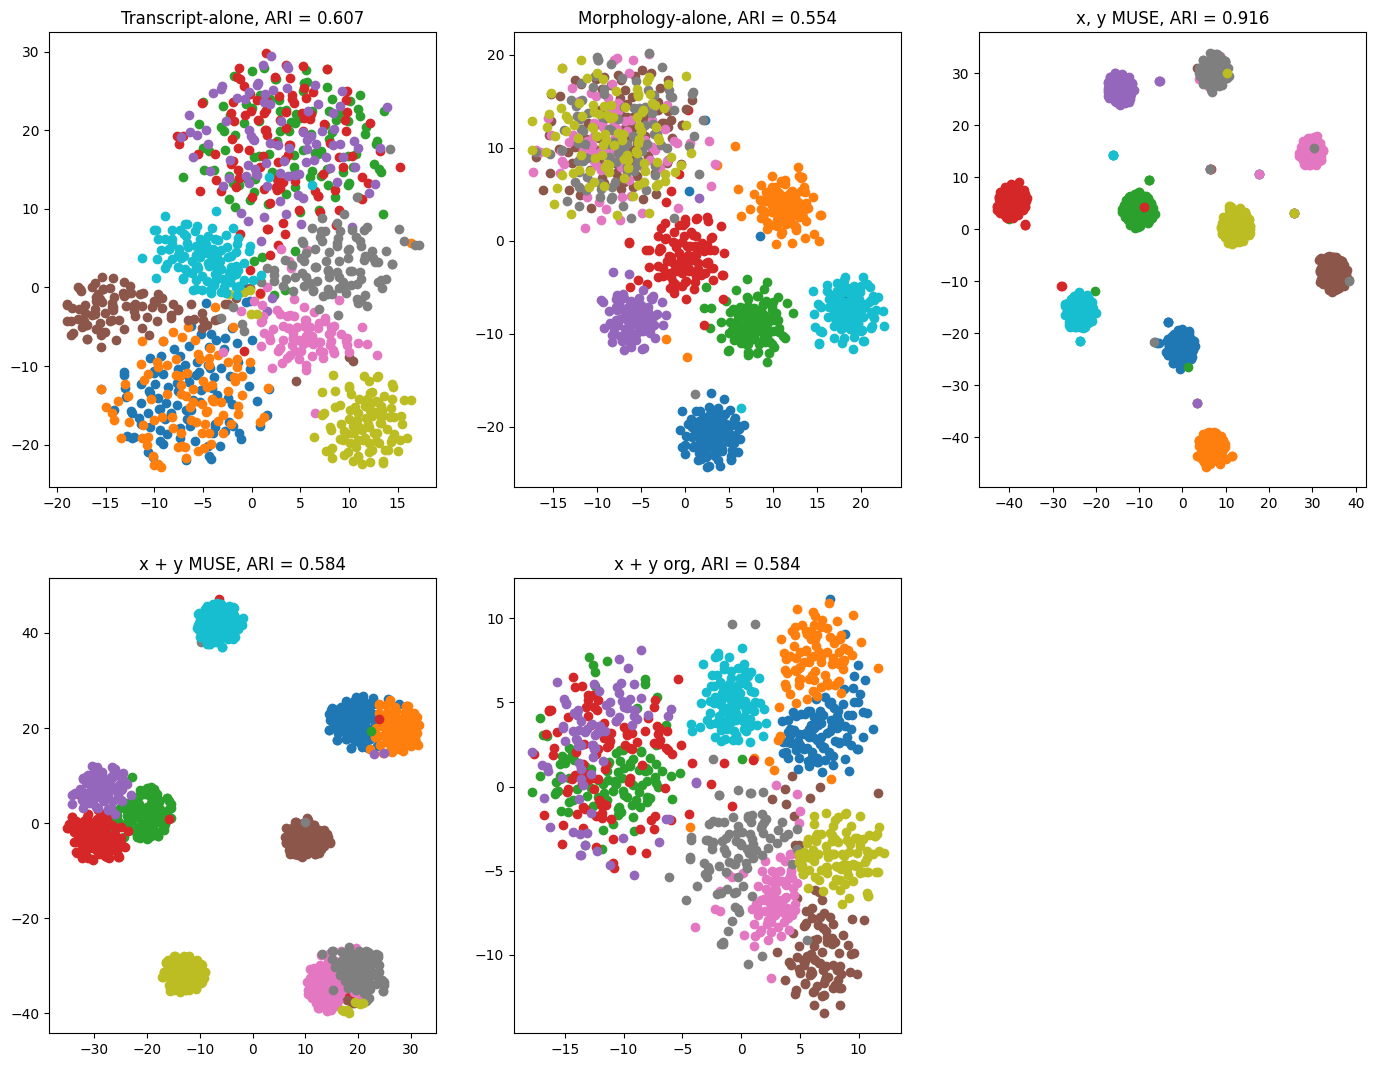

In [13]:
plt.figure(figsize=(17, 13))
plt.subplot(2, 3, 1)
print(f"view_a_feature: {view_a_feature.shape}")
X_embedded = TSNE(n_components=2).fit_transform(view_a_feature)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {label_true.shape}")
print(f"laber_true == i: {(label_true == 0).shape}")
print(f"np.nonzero(label_true == i): {len(np.nonzero(label_true == 2)[0])}")
# 遍历每一个类别
for i in np.unique(label_true):
    # 找到所有类别为i的索引
    idx = np.nonzero(label_true == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Transcript-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_a_label))

plt.subplot(2, 3, 2)
X_embedded = TSNE(n_components=2).fit_transform(view_b_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Morphology-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_b_label))

plt.subplot(2, 3, 3)
X_embedded = TSNE(n_components=2).fit_transform(latent_sc)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('x, y MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_sc))

plt.subplot(2, 3, 4)
X_embedded = TSNE(n_components=2).fit_transform(latent_st)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('x + y MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, muse_label_st))

plt.subplot(2, 3, 5)
X_embedded = TSNE(n_components=2).fit_transform(data_ab)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('x + y org, ARI = %01.3f' % adjusted_rand_score(label_true, view_ab_label))



In [14]:
print('[gene, peak] and [gene+peak] ARI: ', adjusted_rand_score(muse_label_sc, muse_label_st))

[gene, peak] and [gene+peak] ARI:  0.5619186298275682


In [15]:
# 计算cosine_similarity
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc, latent_st)
cos_mapping = cos.argmax(axis=1)
for i in range(len(cos_mapping)):
    if i < 30:
        if i % 5 == 0:
            print()
        print(f"{i:2d}: {cos_mapping[i]:4d}", end="\t")


 0:    0	 1:    1	 2:    2	 3:    3	 4:    4	
 5:    5	 6:    6	 7:    7	 8:    8	 9:    9	
10:   10	11:   11	12:   12	13:   13	14:   14	
15:   15	16:   16	17:   17	18:   18	19:   19	
20:   20	21:   21	22:   22	23:   23	24:   24	
25:   25	26:   26	27:   27	28:   28	29:   29	

In [16]:
# 计算acc
gt = np.array(range(sample_size))
acc = np.sum(cos_mapping == gt) / sample_size
print("cos accuracy:", acc)

cos accuracy: 1.0
